# Exploratory Data Analysis & Preprocessing

**Project**: Transformer Based Protein - Ligand Binding Affinity Prediction

**Notebook purpose**: Explore the Davis drug target interaction dataset before
building the modeling pipeline (ESM-2 + ChemBERTa embeddings -> fusion MLP).

## Dataset
- **Source**: Davis dataset via [Therapeutics Data Commons (TDC)](https://tdcommons.ai/)
- **Task**: Predict binding affinity (pKd) between small-molecule drugs and protein targets
- **Size**: 25,772 drug - target pairs, 68 unique drugs, 379 unique protein targets

## Contents
1. Basic data integrity checks (missing values, duplicates, column types)
2. Target variable (pKd) distribution analysis
3. Drug (SMILES) inspection - format, length, validity via RDKit
4. Protein (sequence) inspection - format, length, amino acid composition
5. Sampling strategy design for the mini training dataset

---

In [ ]:
!pip install -q transformers torch rdkit pandas numpy scikit-learn matplotlib PyTDC

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.2/154.2 kB 14.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.3/151.3 kB 16.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.2/151.2 kB 15.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.2/151.2 kB 16.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.1/151.1 kB 16.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.1/151.1 kB 15.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.1/151.1 kB 14.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.2/151.2 kB 10.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━

In [ ]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")

CUDA available: True
Device: Tesla T4


In [ ]:
from tdc.multi_pred import DTI
import pandas as pd

data = DTI(name='DAVIS')

data.convert_to_log(form='binding') # convert to pKd

df = data.get_data()

print("Total number of samples:", len(df))
print("Unique Count of Drug:", df['Drug_ID'].nunique())
print("Unique Count of Protein:", df['Target_ID'].nunique())
df.head()


Downloading...
100%|██████████| 21.4M/21.4M [00:02<00:00, 7.49MiB/s]
Loading...
Done!
To log space...


Total number of samples: 25772
Unique Count of Drug: 68
Unique Count of Protein: 379


,Drug_ID,Drug,Target_ID,Target,Y
0,11314340,Cc1[nH]nc2ccc(-c3cncc(OCC(N)Cc4ccccc4)c3)cc12,AAK1,MKKFFDSRREQGGSGLGSGSSGGGGSTSGLGSGYIGRVFGIGRQQV...,7.365523
1,11314340,Cc1[nH]nc2ccc(-c3cncc(OCC(N)Cc4ccccc4)c3)cc12,ABL1p,PFWKILNPLLERGTYYYFMGQQPGKVLGDQRRPSLPALHFIKGAGK...,4.999996
2,11314340,Cc1[nH]nc2ccc(-c3cncc(OCC(N)Cc4ccccc4)c3)cc12,ABL2,MVLGTVLLPPNSYGRDQDTSLCCLCTEASESALPDLTDHFASCVED...,4.999996
3,11314340,Cc1[nH]nc2ccc(-c3cncc(OCC(N)Cc4ccccc4)c3)cc12,ACVR1,MVDGVMILPVLIMIALPSPSMEDEKPKVNPKLYMCVCEGLSCGNED...,4.999996
4,11314340,Cc1[nH]nc2ccc(-c3cncc(OCC(N)Cc4ccccc4)c3)cc12,ACVR1B,MAESAGASSFFPLVVLLLAGSGGSGPRGVQALLCACTSCLQANYTC...,4.999996


In [ ]:
# check for missing values
print("Columns:", df.columns.tolist())
print()
print("Missing Values per column:")
print(df.isnull().sum())
print()
print("Duplicate rows:", df.duplicated().sum())
print()
print("Data types:")
print(df.dtypes)

Columns: ['Drug_ID', 'Drug', 'Target_ID', 'Target', 'Y']

Missing Values per column:
Drug_ID      0
Drug         0
Target_ID    0
Target       0
Y            0
dtype: int64

Duplicate rows: 0

Data types:
Drug_ID        int64
Drug          object
Target_ID     object
Target        object
Y            float64
dtype: object


count    25772.000000
mean         5.407419
std          0.826307
min          4.999996
25%          4.999996
50%          4.999996
75%          5.423100
max          9.935542
Name: Y, dtype: float64


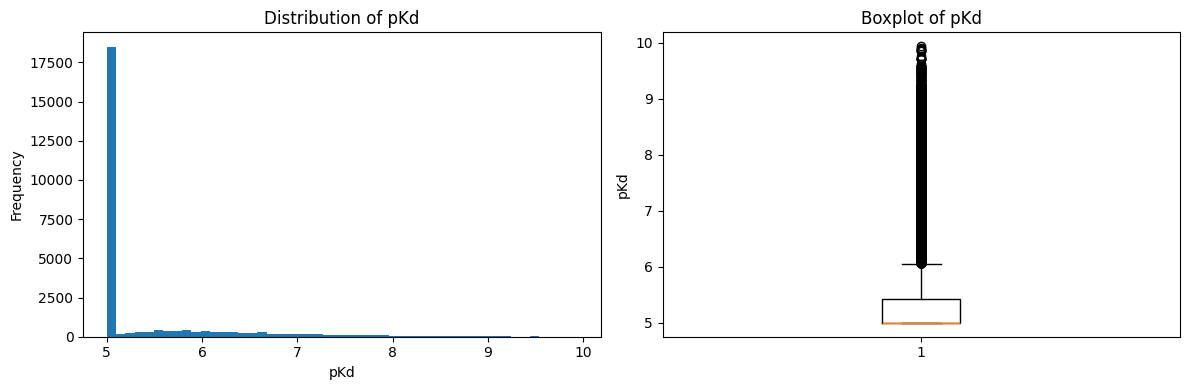

In [ ]:
# target variable distribution(pKd)
import matplotlib.pyplot as plt

print(df['Y'].describe())

fig, ax = plt.subplots(1, 2, figsize=(12,4))

ax[0].hist(df['Y'], bins = 50)
ax[0].set_title('Distribution of pKd')
ax[0].set_xlabel('pKd')
ax[0].set_ylabel('Frequency')

ax[1].boxplot(df['Y'])
ax[1].set_ylabel('pKd')
ax[1].set_title('Boxplot of pKd')

plt.tight_layout()
plt.show()

In [ ]:
# check the molecular structure input before feeding to ChemBERTa
print(df[['Drug_ID', 'Drug']].drop_duplicates().head(10))

# get only the unique SMILES strings
smiles_unique = df['Drug'].drop_duplicates()

# calculate the character length of each SMILES string
smiles_lens = smiles_unique.str.len()

print("\nSMILES length stats:")
print(smiles_lens.describe())

       Drug_ID                                               Drug
0     11314340      Cc1[nH]nc2ccc(-c3cncc(OCC(N)Cc4ccccc4)c3)cc12
379   24889392  CC(C)(C)c1cc(NC(=O)Nc2ccc(-c3cn4c(n3)sc3cc(OCC...
758   11409972  CCN1CCN(Cc2ccc(NC(=O)Nc3ccc(Oc4cc(NC)ncn4)cc3)...
1137  11338033       O=C(NC1CCNCC1)c1[nH]ncc1NC(=O)c1c(Cl)cccc1Cl
1516  10184653  CN(C)CC=CC(=O)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc...
1895   5287969  CN1CCC(c2c(O)cc(O)c3c(=O)cc(-c4ccccc4Cl)oc23)C...
2274   6450551      CNC(=O)c1ccccc1Sc1ccc2c(C=Cc3ccccn3)n[nH]c2c1
2653  11364421  CCC1C(=O)N(C)c2cnc(Nc3ccc(C(=O)NC4CCN(C)CC4)cc...
3032   9926054                   Cc1ccc2nc(NCCN)c3ncc(C)n3c2c1.Cl
3411  16007391  CCN(CCO)CCCOc1ccc2c(Nc3cc(CC(=O)Nc4cccc(F)c4)[...

SMILES length stats:
count    68.000000
mean     54.176471
std      11.043930
min      32.000000
25%      45.000000
50%      53.000000
75%      61.250000
max      81.000000
Name: Drug, dtype: float64


In [ ]:
from rdkit import Chem
from rdkit.Chem import Descriptors

# validate SMILES with RDKit to make sure every SMILES string is chemically valid
invalid_smiles = []

for smiles in smiles_unique:
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        invalid_smiles.append(smiles)

print(f"Total unique SMILES: {len(smiles_unique)}")
print(f"Invalid SMILES: {len(invalid_smiles)}")
if invalid_smiles:
    print(invalid_smiles)

Total unique SMILES: 68
Invalid SMILES: 0


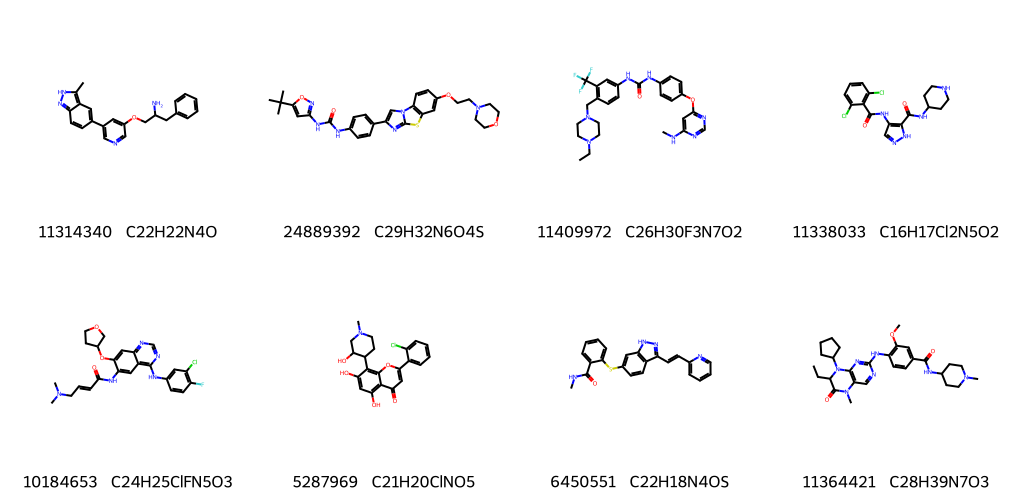

In [ ]:
from rdkit.Chem import Draw
from rdkit.Chem.rdMolDescriptors import CalcMolFormula

# visualize molecule structures
sample_drugs = df[['Drug_ID', 'Drug']].drop_duplicates().head(8)
mols = [Chem.MolFromSmiles(smiles) for smiles in sample_drugs['Drug']]

labels = [
    f"{drug_id}\t{CalcMolFormula(mol)}"
    for drug_id, mol in zip(sample_drugs['Drug_ID'], mols)
]

img = Draw.MolsToGridImage(
    mols,
    molsPerRow=4,
    subImgSize=(256, 250),
    legends=labels
)
img

In [ ]:
# check protein sequence input before feeding it to ESM-2
protein_unique = df[['Target_ID', 'Target']].drop_duplicates()
print(protein_unique.head(5))

# longer sequence take much more time/ memory to run through transformer
seq_lens = protein_unique['Target'].str.len()

print("\nSequence length stats:")
print(seq_lens.describe())

  Target_ID                                             Target
0      AAK1  MKKFFDSRREQGGSGLGSGSSGGGGSTSGLGSGYIGRVFGIGRQQV...
1     ABL1p  PFWKILNPLLERGTYYYFMGQQPGKVLGDQRRPSLPALHFIKGAGK...
2      ABL2  MVLGTVLLPPNSYGRDQDTSLCCLCTEASESALPDLTDHFASCVED...
3     ACVR1  MVDGVMILPVLIMIALPSPSMEDEKPKVNPKLYMCVCEGLSCGNED...
4    ACVR1B  MAESAGASSFFPLVVLLLAGSGGSGPRGVQALLCACTSCLQANYTC...

Sequence length stats:
count     379.000000
mean      744.849604
std       373.299164
min       244.000000
25%       479.500000
50%       632.000000
75%       948.000000
max      2549.000000
Name: Target, dtype: float64


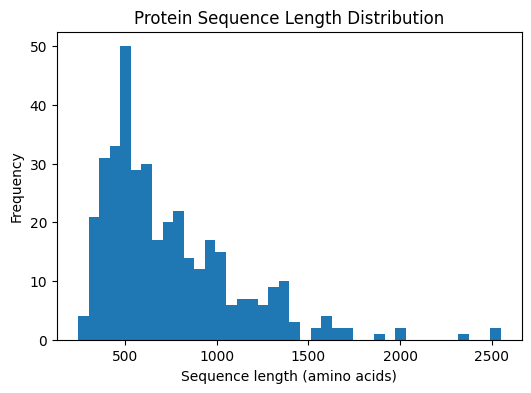

Proteins > 1000 aa: 76
Proteins > 1500 aa: 16

Proteins with non-standard characters: 1


In [ ]:
# check the long tail
# validate amino acid characters
plt.figure(figsize=(6,4))
plt.hist(seq_lens, bins=40)
plt.xlabel('Sequence length (amino acids)')
plt.ylabel('Frequency')
plt.title('Protein Sequence Length Distribution')
plt.show()

# median=632, 75th percentile=948
# ESM-2 was pretrained on sequences typically up to 1024 residues
print("Proteins > 1000 aa:", (seq_lens > 1000).sum())
print("Proteins > 1500 aa:", (seq_lens > 1500).sum())

standard_aa = set("ACDEFGHIKLMNPQRSTVWY")
def has_nonstandard(seq):
    return not set(seq).issubset(standard_aa)

nonstandard_count = protein_unique['Target'].apply(has_nonstandard).sum()
print("\nProteins with non-standard characters:", nonstandard_count)


In [ ]:
# identify the non-standard sequence
standard_aa = set("ACDEFGHIKLMNPQRSTVWY")

for i, r in protein_unique.iterrows():
  seq = r['Target']
  extra_chars = set(seq) - standard_aa
  if extra_chars:
    print(f"Target_ID: {r['Target_ID']}")
    print(f"Non-standard characters found: {extra_chars}")
    print(f"Sequence length: {len(seq)}")

Target_ID: TESK1
Non-standard characters found: {'X'}
Sequence length: 244


## EDA Summary

- **Dataset**: 25,772 drug-target pairs, 68 unique drugs, 379 unique proteins - complete matrix (68 x 379)
- **No missing values, no duplicate rows**
- **Target (pKd) is highly imbalanced**: >70% of samples sit at the detection
  floor (pKd ~ 5). Requires **stratified sampling** for the mini dataset.
- **Drugs (SMILES)**: all 68 valid (RDKit-confirmed), short (32-81 chars),
  well within ChemBERTa's input limits.
- **Proteins (sequences)**: wide length range (244-2549 aa, median 632).
  Decided **not to truncate** - small dataset,truncating would discard information from 76 of them (~20%), which is a significant fraction to lose for such a small dataset.. One protein (TESK1)
  contains a single non-standard 'X' character, handled natively by
  ESM-2's tokenizer.

**Next step**: design the stratified sampling strategy for the mini
training dataset (~1,000 - 1,500 pairs), ensuring coverage across the full
pKd range before extracting ESM-2/ChemBERTa embeddings.

---

In [ ]:
# build the training dataset

TARGET_SIZE = 6000

n_bins = 5
df['pKd_bin'] = pd.cut(df['Y'], bins=n_bins, labels=False)

print(df['pKd_bin'].value_counts().sort_index())

samples_per_bin = TARGET_SIZE // n_bins

mini_df = (
    df.groupby('pKd_bin', group_keys=False)
      .apply(lambda x: x.sample(n=min(len(x), samples_per_bin), random_state=42))
)

print(f"Mini dataset size: {len(mini_df)}")
print(f"Unique drugs: {mini_df['Drug_ID'].nunique()} / 68")
print(f"Unique proteins: {mini_df['Target_ID'].nunique()} / 379")
print("\npKd distribution:")
print(mini_df['Y'].describe())


pKd_bin
0    21354
1     2573
2     1208
3      494
4      143
Name: count, dtype: int64
Mini dataset size: 4237
Unique drugs: 68 / 68
Unique proteins: 379 / 379

pKd distribution:
count    4237.000000
mean        6.640603
std         1.235356
min         4.999996
25%         5.259629
50%         6.638083
75%         7.521434
max         9.935542
Name: Y, dtype: float64


## Mini Dataset Summary

- **Size**: 4,237 drug-target pairs (down from 25,772, via stratified
  sampling on pKd)
- **Coverage**: 68/68 unique drugs, 379/379 unique proteins — full coverage,
  no information loss on the drug/protein side
- **pKd distribution after sampling**: mean=6.64, median=6.64 (up from
  mean=5.41, median=5.00 in the full dataset),high-affinity samples are
  no longer drowned out by the detection floor majority
- **Note**: distribution still skews toward the floor by design (real
  screening data), but bin 4 (rarest, strongest binders) contributes all
  143 available samples rather than being diluted
---

In [ ]:
mini_df = mini_df.drop(columns=['pKd_bin'])
mini_df.to_csv('davis_mini.csv', index=False)

In [ ]:
print(len(mini_df))
mini_df.head()

4237


,Drug_ID,Drug,Target_ID,Target,Y
13009,11712649,O=C(O)c1ccc(Nc2ncc3c(n2)-c2ccc(Cl)cc2C(c2c(F)c...,FES,MGFSSELCSPQGHGVLQQMQEAELRLLEGMRKWMAQRVKSDREYAG...,4.999996
2629,6450551,CNC(=O)c1ccccc1Sc1ccc2c(C=Cc3ccccn3)n[nH]c2c1,TRKA,MLRGGRRGQLGWHSWAAGPGSLLAWLILASAGAAPCPDACCPHGSS...,5.744703
20375,10138260,Cc1[nH]c(C=C2C(=O)Nc3ccc(F)cc32)c(C)c1C(=O)NCC...,PRKCI,MPTQRDSSTMSHTVAGGGSGDHSHQVRVKAYYRGDIMITHFEPSIS...,4.999996
6993,156422,Cc1ccc(-n2nc(C(C)(C)C)cc2NC(=O)Nc2ccc(OCCN3CCO...,LKB1,MEVVDPQQLGMFTEGELMSVGMDTFIHRIDSTEVIYQPRRKRAKLI...,4.999996
22284,16038120,COc1cc(N2CCC(N3CCN(C)CC3)CC2)ccc1Nc1ncc(Cl)c(N...,RIOK1,MDYRRLLMSRVVPGQFDDADSSDSENRDLKTVKEKDDILFEDLQDN...,4.999996
